<CENTER><img src="https://github.com/atlas-outreach-data-tools/notebooks-collection-opendata/blob/master/images/ATLASOD.gif?raw=1" style="width:50%"></CENTER>

# Fake Leptons
In this notebook, we will go over what a "fake lepton" is, where they come from, how to find them, and ways that we filter them out! By the end, you'll be an expert in managing fake leptons, and be able to find them in detector data.

### What are leptons?
In the [Standard Model of particle physics](https://opendata.atlas.cern/docs/documentation/introduction/SM_and_beyond), the lepton group consists of six distinct particle flavors. The charged leptons: electron, muon, and tau particle; as well as the uncharged/neutral set of neutrinos for each of the aforementioned particles. Since the ATLAS detector is not a dedicated neutrino detector, we generally will not see neutrinos pop up in analysis, so in terms of the leptons we consider we will focus on the electron, muon, and tau. Leptons are characterized by their lack of interaction with the [strong force](https://en.wikipedia.org/wiki/Strong_interaction), and each also has their own [antiparticle](https://en.wikipedia.org/wiki/Antiparticle). Being some of the most abundant particles in physics, leptons are an integral part of physics analysis, and having an accurate record of leptons in an event is central in suppressing backgrounds and searching for new physics.

### What's the deal with fake leptons?
Counting up these leptons and keeping an accurate record doesn't always go our way. In the case that we get a few extras in our record that we don't really want, we call these "fake leptons", though there are some more specific names depending on the situation. 

Sometimes, after a collision, we might get a few extra leptons that do not originate from the hard-scattering process, but instead come from secondary decays later in the event, such as hadronic decays/jets, meson decay, or photon conversion, creating extra leptons which we detect. We call these “non-prompt” leptons. They are still part of the same collision event, but they do not originate from the prompt process we are studying. 

Sometimes, a particle from the hard scatter will be misidentified as a lepton, when in reality they are just a hadron or a jet. These create situations where leptons are reconstructed from non-lepton objects. These non-prompt leptons and leptons from misidentification, if kept in our analysis, can contaminate the selected event sample, increase systematic uncertainty, and cause physical processes to be misidentified. In keeping accurate data, it's important that we do everything we can to suppress or estimate these background contributions. 

In this notebook, we will look at examples of both non-prompt and misidentified leptons, and learn how to identify and characterize them in an analysis.

### Running a Jupyter Notebook

To run the whole Jupyter notebook, in the top menu click Cell $\rightarrow$ Run All.

To propagate a change you've made to a piece of code, click Cell $\rightarrow$ Run All Below.

You can also run a single code cell, by using the keyboard shortcut Shift+Enter.

### First time setup on your computer (Skip on MyBinder)
This first cell only needs to be run the first time you open this notebook on your computer.

If you close Jupyter and re-open it on the same computer, you won't need to run this first cell again.

If you open the notebook on mybinder, you don't need to run this cell.

In [ ]:
#install required packages
import sys
%pip install atlasopenmagic
from atlasopenmagic import install_from_environment
install_from_environment()

### To setup everytime
We're going to be using a number of tools to help us:
* urllib: let us download files
* uproot: lets us read .root files typically used in particle physics into data formats used in Python
* pandas: lets us store data as dataframes, a format widely used in Python
* numpy: provides numerical calculations such as histogramming
* matplotlib: common tool for making plots, figures, images, visualisations
* awkward: a python package for dealing conveniently with lists that are different lengths
* vector: a python package for making and manipulating vectors

In case you see an error when importing one of these packages, try restarting the kernel (the "session" in Colab) to make sure the packages that were installed in the last cell have been properly loaded.

In [2]:
import pandas as pd # to store data as dataframes
import numpy as np # for numerical calculations such as histogramming
import uproot # to read .root files as dataframes
import matplotlib.pyplot as plt # for plotting
from matplotlib.ticker import MaxNLocator,AutoMinorLocator # for minor ticks
import awkward as ak # for handling complex and nested data structures efficiently
import vector # For convenient 4-vector manipulation

## Top-Antitop Production
To look at how fake or non-prompt leptons appear, we'll start with the most common and easily identifiable case. 

<div align="center"><img src="https://feynm.net/wp-content/uploads/2025/09/ttbar-008.png" style="width:50%"></div>

<small>Credit: feynm.net and LaTeX.org</small>

Top-Antitop Production (commonly referred to as ttbar production) is most often a byproduct of gluon fusion during the collision of protons at high energies, like at the LHC. Drawn above is a [Feynman Diagram](https://cds.cern.ch/record/2759490/files/Feynman%20Diagrams%20-%20ATLAS%20Cheat%20Sheet.pdf) of the primary decay channel for ttbar production. As is shown, both top quarks decay into oppositely charged W bosons, as well as a bottom or antibottom quark. W bosons can decay into either quarks, or less commonly, a lepton-neutrino pair, creating our prompt leptons. However, the bottom/antibottom quark pair will also hadronize and create b-jets, which can create semileptonically decaying hadrons, generating extra leptons. Generally, we account for the leptonic decay of the W bosons as this is considered part of the initial decay, however these "extra leptons" which appear from hadronic decay in a smaller percentage of cases are considered non-prompt, and must be removed.


### Let's Get Some Data!
We're going to use the `atlasopenmagic` package to acquire and cache our data. This is a custom package designed by ATLAS Open Data to allow easy access to ATLAS public datasets. 

In [ ]:
# Let's start by importing atlasopenmagic so we can search for our data.
import atlasopenmagic as atom
# We're gonna set our release to a specific version, as there's a good example dataset in this one.
atom.set_release('2025e-13tev-beta')

### Finding Data
Let's start by finding some data that would most likely have some non-prompt leptons mixed in.

In [ ]:
# We can start by searching in the metadata for data surrounding ttbar production, our most common non-prompt lepton event.
atom.match_metadata(field='keywords',value='ttbar')

That's a good amount of options! However, we also want to make sure our data contains prompt leptons as well. For this, we'll use the dataset labeled "nonallhad", meaning that at least one of the W bosons decays non-hadronically, giving us a mix of prompt and non-prompt leptons to check for.

In [5]:
# Let's load our data. We set cache to false so we only grab events that we request, instead of loading the entire 16 GB dataset.
files_list = atom.get_urls('PhPy8EG_A14_ttbar_hdamp258p75_nonallhad', protocol='root', cache=False)

# Here we'll build a tree using the files we just pulled, using uproot to view the root files.
ttbar_tree = uproot.open(files_list[0])["analysis"]

# And we'll print the amount of events available to choose from
print(f"Events available: {ttbar_tree.num_entries:,}")

Events available: 32,787,327


That's more than enough events to visualize the phenomenon we're looking for. Let's grab 1,000,000 of these events, and require at least 20.0 GeV of transverse momentum, so we primarily see high-energy leptons that could have been produced by W boson decay, the prompt event we're looking for. If our sample only contains prompt leptons, then what we should see is a distribution of most events with either 0 or 1 lepton and very few with 2 leptons. This is because both W bosons decaying leptonically is quite rare, with a 33% chance of any W boson decaying leptonically. We should also see 0 events with more than 2 leptons, as this should be impossible if we are only seeing prompt leptons. As prompt leptons can only come from the two W bosons in the ttbar events we are looking at, events with more than 2 leptons indicate the presence of non-prompt leptons in our data.     

In [6]:
pt_cut = 20.0  # GeV
max_events = 1_000_000  # Change to None to run over all events

# We'll load the event counts without loading the whole ROOT file into memory.
multiplicity_counts = np.zeros(1, dtype=np.int64)
events_processed = 0

# We'll define what variable we're searching in, our step size, our limit, and what library we'll be using.
for batch in ttbar_tree.iterate(
    expressions=["lep_pt"],
    entry_stop=max_events,
    step_size=100_000,
    library="ak",
):
    # lep_pt is jagged: each event can contain a different number of leptons.
    n_leptons = ak.to_numpy(ak.sum(batch["lep_pt"] > pt_cut, axis=1))
    batch_counts = np.bincount(n_leptons)

    if len(batch_counts) > len(multiplicity_counts):
        multiplicity_counts = np.pad(
            multiplicity_counts, (0, len(batch_counts) - len(multiplicity_counts))
        )
    multiplicity_counts[:len(batch_counts)] += batch_counts
    events_processed += len(n_leptons)

### Plotting
Now that the data is processed for us, we'll plot it and look at what we actually see in the data. The below code will generate a bar graph of lepton counts in reconstructed events.

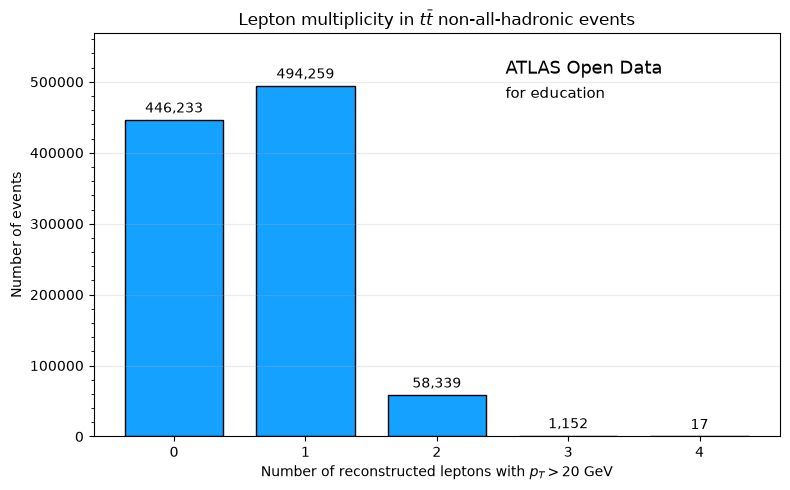

In [7]:

n_values = np.arange(len(multiplicity_counts))

# This defines the values for our plot, and sets the most basic information
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    n_values, multiplicity_counts, width=0.75,
    color="#15A1FF", edgecolor="black"
)

# Here we fill out our plot with labels, max axis numbers, and other cosmetic parameters 
ax.set_xlabel(r"Number of reconstructed leptons with $p_T > 20$ GeV")
ax.set_ylabel("Number of events")
ax.set_title(r"Lepton multiplicity in $t\bar{t}$ non-all-hadronic events")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid(axis="y", alpha=0.25)
ax.bar_label(bars, labels=[f"{count:,}" for count in multiplicity_counts], padding=3)
ax.set_ylim(0, max(multiplicity_counts) * 1.15)

# Add text 'ATLAS Open Data' on plot
ax.text(
    0.60,
    0.90,
    "ATLAS Open Data",
    transform=ax.transAxes,fontsize=13,)


# Add text 'for education' on plot
ax.text(
    0.60,
    0.84,
    "for education",
    transform=ax.transAxes,fontsize=11,)

# This just plots the defined info and displays it
plt.tight_layout()
plt.show()

That's not quite what we should be expecting. However as you can see from the presence of events with 3 or 4 leptons, we have evidence to support the presence of non prompt leptons! We'll go over how we can manage this soon enough, but first let's see another way we can get contamination from fake leptons.

## Photon Conversion

<div style="display: flex; justify-content: center; align-items: center; gap: 20px;"><img src="https://github.com/atlas-outreach-data-tools/notebooks-collection-opendata/blob/master/13-TeV-examples/uproot_python/images/feynman_diagrams/H_toploop_yy_feyn.png?raw=true" style="width: 40%;"><img src="https://github.com/atlas-outreach-data-tools/notebooks-collection-opendata/blob/master/13-TeV-examples/uproot_python/images/feynman_diagrams/H_Wloop_yy_feyn.png?raw=true" style="width: 40%;">
</div>

Another significant source of non prompt leptons is from the decay of the Higgs Boson. Once used to identify the Higgs boson in 2012, the Higgs to diphoton decay channel is another, rarer decay mode that happens in about 0.2% of Higgs decays. The Higgs boson has a very short lifetime, and rapidly decays into one of many modes, in some rare cases decaying into two photons, which is most commonly mediated by a loop usually involving top quarks or W bosons (shown above). 

Sometimes, when one of these high energy photons passes by another electric field, atomic nucleus, or they collide with eachother, they will split into leptons. This is known as [Pair Production](https://en.wikipedia.org/wiki/Pair_production), and is a result of the high energy in these photons due to the decay of the 125 GeV Higgs boson. These leptons can then be picked up by the ATLAS detector, and result in non-prompt lepton signals.

### Getting H $\rightarrow$ yy Data

More often than not, we refer to the Higgs diphoton decay channel as simply "Hyy" or "H->gamgam" to save us some space in the database ("yy" because the greek symbol gamma, "$\gamma$", looks like the letter y). Since we have a lot of data to choose from, lets search for datasets with "Hyy" in the title using the `match_metadata` command in `Atlasopenmagic`.

In [ ]:
# Match metadata will search for all of the datasets which contain a string or value given.
atom.match_metadata(field='physics_short',value='Hyy')

Looks like we have a good selection here. We'll go with the sample which includes only Hyy, without other decay channels included. Remember, we're only looking at non-prompt leptons from Higgs decay to photons. Including other variables like W or Z boson decay could create extra leptons in our range of analysis, inflating the number of non-prompt events present. 

In this analysis, what we'll mainly be looking for is a signature from non-prompt leptons produced from pair production. We're going to compare the mass of events with two photons, and events with a photon and an electron. Since we're looking at higgs decays, we'll most likely see a large jump in the amount of diphoton events that hover around 125 GeV in mass (the mass of the Higgs boson). If a significant amount of photons convert into electrons, then we'll also see a jump in the amount of photon-electron events at that same 125 GeV mass.

In [9]:
# We'll define our files under a different variable, and use the files listed under our chosen dataset.
hyy_files = atom.get_urls("aMCH7EG_VBF_HC_Hyy",protocol="root",cache=False)

Great! Now we'll run some code to load the variables that we need and define some basic functions. We have a function which creates four-vectors, a kind of vector which shows the momentum, direction, and energy, and a function which orders particles by highest transverse momentum.

In [10]:
# Only load the information needed for this demonstration.
variables = [
    "photon_pt",
    "photon_eta",
    "photon_phi",
    "photon_e",
    "photon_isLooseID",
    "lep_type",
    "lep_pt",
    "lep_eta",
    "lep_phi",
    "lep_e",
    "lep_isLooseID",
]

# Define a function to generate four-vectors.
def make_four_vectors(pt, eta, phi, energy):
    return vector.zip({
        "pt": pt,
        "eta": eta,
        "phi": phi,
        "e": energy,
    })

# Place the highest transverse momentum first in the list of particles.
def sort_by_pt(particles):
    order = ak.argsort(
        particles.pt,
        axis=1,
        ascending=False,
    )
    return particles[order]

### Data Processing
The following code is going to load our dataset in chunks of 10,000 events at a time. We'll construct [four-vectors](https://cds.cern.ch/record/2919871/files/4-vectors%20and%20invariant%20mass%20cheat%20sheet.pdf) for each photon and electron/positron, select good particles by applying a cut to keep particles with transverse momentum above 20 GeV, and calculate invariant mass. By splitting up events by particle type, we end up with two bins: one containing the ordered invariant mass of diphoton events, and one containing the ordered invariant mass of events with one photon and one electron. 

For this analysis, we group electrons and positrons together, as they are nearly identical to the detector, and their charge is stored in a separate variable which is of no need to this analysis. If you want to know more about 4-vectors and invariant mass, check out our other notebook, [Find the Z](https://opendata.atlas.cern/docs/13TeV25Doc/StandardModel), where we dive deeper into what these things are. For this notebook, what we need to know is that the invariant mass of a particle is simply the combined energy and mass of a particle. 

Note: This cell may take some time to run, allow 1-2 minutes for processing.

In [ ]:
# We can first define empty lists where we'll place our values
diphoton_mass_list = []
electron_photon_mass_list = []

# We'll process by recursively running through every file in the file list
for file_number, file_name in enumerate(
    hyy_files,
    start=1,
):
    # Pull the files again using uproot
    hyy_tree = uproot.open(file_name + ":analysis")

    # Define our step size, load the variables we need, and load our library
    for data in hyy_tree.iterate(
        variables,
        step_size=10_000,
        library="ak",
    ):
        # We'll construct four vectors for photons using the variables we defined earlier
        photons = make_four_vectors(
            data["photon_pt"],
            data["photon_eta"],
            data["photon_phi"],
            data["photon_e"],
        )

        # And then again for our electrons
        electrons = make_four_vectors(
            data["lep_pt"],
            data["lep_eta"],
            data["lep_phi"],
            data["lep_e"],
        )

        # Photon selection
        good_photon = (
            (photons.pt > 20)
            & (abs(photons.eta) < 2.37)
            & data["photon_isLooseID"]
        )

        # Electron selection
        good_electron = (
            (abs(data["lep_type"]) == 11)
            & (electrons.pt > 20)
            & (abs(electrons.eta) < 2.47)
            & data["lep_isLooseID"]
        )

        # Sort photons by transverse momentum
        photons = sort_by_pt(
            photons[good_photon]
        )

        # Sort electrons by transverse momentum
        electrons = sort_by_pt(
            electrons[good_electron]
        )

        # H -> gamma gamma reconstruction
        has_two_photons = (
            ak.num(photons, axis=1) >= 2
        )

        diphoton_events = photons[
            has_two_photons
        ]

        diphoton_mass = (
            diphoton_events[:, 0]
            + diphoton_events[:, 1]
        ).M

        diphoton_mass_list.append(
            diphoton_mass
        )

        # Electron-photon reconstruction
        has_electron_and_photon = (
            (ak.num(electrons, axis=1) >= 1)
            & (ak.num(photons, axis=1) >= 1)
        )

        electron_photon_electrons = electrons[
            has_electron_and_photon
        ]

        electron_photon_photons = photons[
            has_electron_and_photon
        ]

        electron_photon_mass = (
            electron_photon_electrons[:, 0]
            + electron_photon_photons[:, 0]
        ).M

        electron_photon_mass_list.append(
            electron_photon_mass
        )

print("Finished processing the sample.")

### Plotting!
Now that our data is processed and ready, we plot! The following code creates a template graph, which we can load either our diphoton or photon-electron data into. With this, we can create two graphs, and directly compare them to see if we get that bump in photon-electron events around our Higgs mass of 125 GeV.

In [12]:
# Combine the masses collected for diphoton events.
full_diphoton_mass = ak.concatenate(
    diphoton_mass_list
)

# Combine the masses for electron-photon events.
full_electron_photon_mass = ak.concatenate(
    electron_photon_mass_list
)

# Define the base plot, binning, and range
def plot_mass_distribution(
    full_mass_list,
    x_axis_label,
    plot_title,
):
    bin_width = 1  # GeV

    bin_edges = np.arange(
        start=100,
        stop=161,
        step=bin_width,
    )

    bin_centres = (
        bin_edges[:-1] + bin_edges[1:]
    ) / 2

    # Histogram the simulated events.
    event_counts, _ = np.histogram(
        ak.to_numpy(full_mass_list),
        bins=bin_edges,
    )

    # Statistical uncertainty on each bin.
    event_count_errors = np.sqrt(
        event_counts
    )

    fig, main_axes = plt.subplots(
        figsize=(8, 6)
    )

    # Set up the error bars for the plots
    main_axes.errorbar(
        x=bin_centres,
        y=event_counts,
        yerr=event_count_errors,
        fmt="ko",
        label="Signal simulation",
    )

    # Setting up limits, parameters, and labels for our base plot
    main_axes.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True,
    )

    main_axes.set_xlim(
        bin_edges[0],
        bin_edges[-1],
    )

    main_axes.set_xlabel(
        x_axis_label,
        fontsize=13,
        x=1,
        horizontalalignment="right",
    )

    main_axes.set_ylabel(
        f"Events / {bin_width} GeV",
        fontsize=13,
        y=1,
        horizontalalignment="right",
    )

    main_axes.set_title(plot_title)
    main_axes.set_yscale("log")
    main_axes.set_ylim(bottom=0.7)

    main_axes.xaxis.set_minor_locator(
        AutoMinorLocator()
    )

    # Add "ATLAS Open Data" text
    main_axes.text(
        0.05,
        0.90,
        "ATLAS Open Data",
        transform=main_axes.transAxes,
        fontsize=13,
    )

    # Add "For Education" text
    main_axes.text(
        0.05,
        0.86,
        "for education",
        transform=main_axes.transAxes,
        fontsize=10,
    )

    main_axes.legend(frameon=False)

    # Allow the functions to plot and appear on screen
    plt.tight_layout()
    plt.show()

### Diphoton Plot

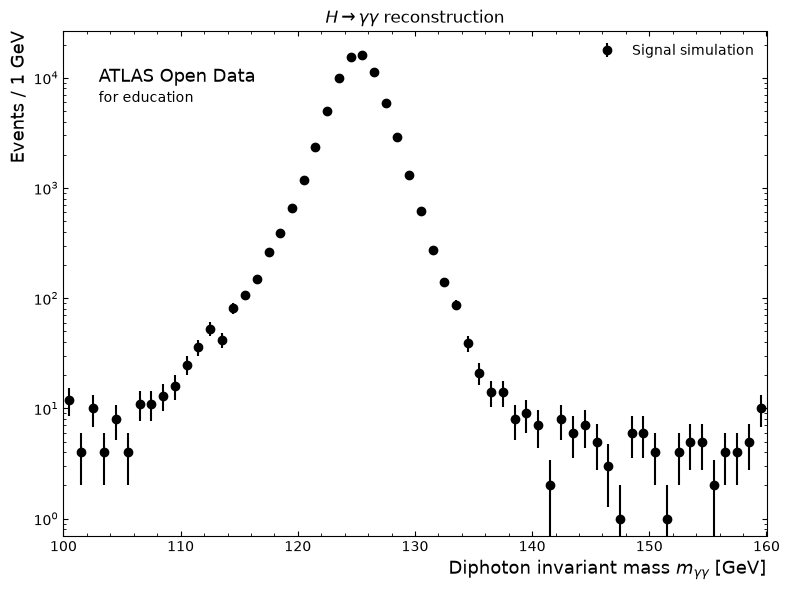

In [13]:
# Load our base plot with the diphoton masses and assign accuate labels
plot_mass_distribution(
    full_diphoton_mass,
    r"Diphoton invariant mass $m_{\gamma\gamma}$ [GeV]",
    r"$H\rightarrow\gamma\gamma$ reconstruction",
)

### Photon Electron Plot

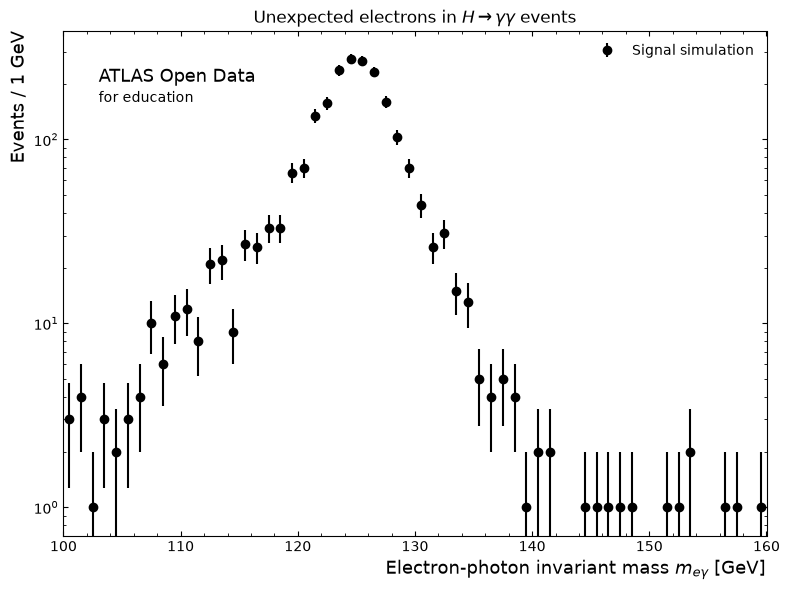

In [14]:
# Load our base plot with the electron-photon distribution and assign accurate labels
plot_mass_distribution(
    full_electron_photon_mass,
    r"Electron-photon invariant mass $m_{e\gamma}$ [GeV]",
    r"Unexpected electrons in $H\rightarrow\gamma\gamma$ events",
)

There it is! As expected, the diphoton distribution shows peak near 125 GeV, indicating photon production via Higgs decay. However, a smaller peak appears at the same mass in the electron–photon distribution. This shows that a significant amount of Higgs decays likely resulted in pair production from photon conversion, creating non-prompt leptons and resulting in higher-than-expected lepton counts. 

## Misidentified Objects

Like we said earlier, sometimes things get misidentified as a lepton, when they are actually other physics objects labelled incorrectly by the detector. Here, we'll utilize leptons in the truth record and match them to our reconstructed leptons and see how many objects have been misidentified as a lepton. If our sample includes misidentified leptons, some of our reconstructed leptons will not match our truth record, as the truth record contains the simulated data we are using to reconstruct the events. For more information on what the "truth record" is, visit our page on the [Monte Carlo Production Chain](https://opendata.atlas.cern/docs/documentation/monte_carlo/MC_production_chain).

### Truth Matching

Let's take a closer look at what we're actually looking for: Truth leptons are simulated via the Monte Carlo simulation pipeline, creating accurate representations of what should be happing in a signal event. We then use these to reconstruct the data from the ATLAS detector, and analyze what is happening. Sometimes, detector data will appear to line up with a lepton, signature, but will not have a matching truth lepton to reconstruct the event. These can sometimes be explained by misidentification, and the presence of detected leptons which we cannot match to a truth lepton could indicate contributions from this in our analysis.

Here we'll reuse the earlier ttbar sample to check if we had any physics objects misidentified as leptons in our prior analysis. We'll start by loading the sample from earlier and rebuilding the data tree.

In [ ]:
# Get the files from the dataset again
truthmatching_files = atom.get_urls("410470",protocol="root",cache=False,)

# Build a tree using the data in our sample
truthmatching_tree = uproot.open(truthmatching_files[0])["analysis"]

# Print how many events we gathered
print(
    f"ttbar events available: "
    f"{truthmatching_tree.num_entries:,}"
)

### How do we decide if two leptons match?

A truth lepton and a reconstructed lepton should have the same flavor and similar properties. We first compare their directions using the angular distance between them, represented by  $\Delta R$.

$$
\Delta R = \sqrt{(\Delta\eta)^2 + (\Delta\phi)^2}
$$

A smaller $\Delta R$ means that the particles point in similar directions through the detector.

For this demonstration, a reconstructed lepton is considered matched when:

- It is the same type of lepton as the truth lepton (i.e. flavor)
- Their angular separation satisfies $\Delta R < 0.1$
- Their transverse momenta differ by less than 50%

These requirements air on the simple side; a full-scale published analysis will have more exacting requirements than this, 

In [16]:
def make_particle_list(pt, eta, phi):
    # Store the particle properties needed for matching
    return ak.zip({
        "pt": pt,
        "eta": eta,
        "phi": phi,
    })


def match_to_truth(
    reco_particles,
    truth_particles,
):
    # Make every possible reconstructed-truth pair within each event
    pairs = ak.cartesian(
        {
            "reco": reco_particles,
            "truth": truth_particles,
        },
        axis=1,
        nested=True,
    )

    delta_eta = (
        pairs.reco.eta
        - pairs.truth.eta
    )

    # Calculate delta-phi while accounting for the boundary between -pi and +pi
    delta_phi = np.arctan2(
        np.sin(
            pairs.reco.phi
            - pairs.truth.phi
        ),
        np.cos(
            pairs.reco.phi
            - pairs.truth.phi
        ),
    )

    delta_r = np.sqrt(
        delta_eta**2
        + delta_phi**2
    )

    relative_pt_difference = (
        abs(
            pairs.reco.pt
            - pairs.truth.pt
        )
        / pairs.truth.pt
    )

    possible_match = (
        (delta_r < 0.1)
        & (relative_pt_difference < 0.5)
    )

    # A reconstructed particle is matched if it has at least one compatible truth particle
    return ak.any(
        possible_match,
        axis=2,
    )

### Applying the truth match

We'll apply the same $p_T>20$ GeV requirement used in our prior analysis. Electrons will be compared only with truth electrons, and muons will becompared only with truth muons.

For each reconstructed candidate, there are two possible outcomes:

- Matched: A compatible truth lepton was found in the same event.
- Unmatched: No compatible truth lepton was found using our requirements.

A matched candidate represents a real generated lepton, but the match alone does not tell us where that lepton came from. The matched category can contain both prompt leptons from \(W\)-boson decays and non-prompt leptons from secondary decays, which we discussed prior.

The unmatched category will contain significant misidentified objects, but an unmatched candidate is not automatically fake. Detector resolution, incomplete truth information, or our matching requirements may also prevent a genuine lepton from being matched.

In [ ]:
truth_variables = [
    "lep_pt",
    "lep_eta",
    "lep_phi",
    "lep_type",
    "truth_elec_pt",
    "truth_elec_eta",
    "truth_elec_phi",
    "truth_muon_pt",
    "truth_muon_eta",
    "truth_muon_phi",
]

pt_cut = 20.0  # GeV

# Define a limit to lower processing times
truth_match_max_events = 1_000_000
truth_match_batch_size = 100_000

# Index 0 represents electrons.
# Index 1 represents muons.
truth_counts = np.zeros(
    2,
    dtype=np.int64,
)

reco_counts = np.zeros(
    2,
    dtype=np.int64,
)

matched_counts = np.zeros(
    2,
    dtype=np.int64,
)

unmatched_counts = np.zeros(
    2,
    dtype=np.int64,
)

events_truth_matched = 0

for batch in truthmatching_tree.iterate(
    expressions=truth_variables,
    entry_stop=truth_match_max_events,
    step_size=truth_match_batch_size,
    library="ak",
):
    events_truth_matched += len(
        batch["lep_pt"]
    )

    # Construct the reconstructed-lepton collection.
    reco_leptons = ak.zip({
        "pt": batch["lep_pt"],
        "eta": batch["lep_eta"],
        "phi": batch["lep_phi"],
        "kind": batch["lep_type"],
    })

    # Apply the same pT requirement used in the lepton-multiplicity graph.
    reco_leptons = reco_leptons[
        reco_leptons.pt > pt_cut
    ]

    # Separate reconstructed electrons and muons.
    reco_electrons = reco_leptons[
        abs(reco_leptons.kind) == 11
    ]

    reco_muons = reco_leptons[
        abs(reco_leptons.kind) == 13
    ]

    # Construct the truth-particle collections.
    truth_electrons = make_particle_list(
        batch["truth_elec_pt"],
        batch["truth_elec_eta"],
        batch["truth_elec_phi"],
    )

    truth_muons = make_particle_list(
        batch["truth_muon_pt"],
        batch["truth_muon_eta"],
        batch["truth_muon_phi"],
    )

    # Match reconstructed objects only to truth particles of the same flavor.
    matched_electrons = match_to_truth(
        reco_electrons,
        truth_electrons,
    )

    matched_muons = match_to_truth(
        reco_muons,
        truth_muons,
    )

    # Count truth particles above 20 GeV.
    truth_counts[0] += int(
        ak.sum(
            truth_electrons.pt > pt_cut
        )
    )

    truth_counts[1] += int(
        ak.sum(
            truth_muons.pt > pt_cut
        )
    )

    # Count reconstructed candidates above 20 GeV.
    reco_counts[0] += int(
        ak.sum(
            ak.num(
                reco_electrons,
                axis=1,
            )
        )
    )

    reco_counts[1] += int(
        ak.sum(
            ak.num(
                reco_muons,
                axis=1,
            )
        )
    )

    # Count matched candidates.
    matched_counts[0] += int(
        ak.sum(matched_electrons)
    )

    matched_counts[1] += int(
        ak.sum(matched_muons)
    )

    # Count reconstructed candidates without a match.
    unmatched_counts[0] += int(
        ak.sum(~matched_electrons)
    )

    unmatched_counts[1] += int(
        ak.sum(~matched_muons)
    )

    print(
        f"\rEvents processed: "
        f"{events_truth_matched:,} / "
        f"{truth_match_max_events:,}",
        end="",
    )

print("\nFinished truth matching.") 

### Data Enumeration and Plotting

Here we'll recieve our processed data, and plot it similar to how we did before. We'll see two bars, one for electrons and one for muons. Each will have a separate colored section for matched and unmatched lepton candidates. 

Before viewing the result, what should we expect? Will one particle type have more unmatched candidates than the other, and why? How close will the matched and unmatched fractions be?

In [ ]:
particle_names = [
    "Electrons",
    "Muons",
]

print(
    f"Events processed: "
    f"{events_truth_matched:,}\n"
)

for index, particle_name in enumerate(
    particle_names
):
    match_fraction = (
        matched_counts[index]
        / reco_counts[index]
        if reco_counts[index] > 0
        else 0
    )

    print(particle_name)

    print(
        f"  Truth particles above 20 GeV: "
        f"{truth_counts[index]:,}"
    )

    print(
        f"  Reconstructed candidates: "
        f"{reco_counts[index]:,}"
    )

    print(
        f"  Matched candidates: "
        f"{matched_counts[index]:,}"
    )

    print(
        f"  Unmatched candidates: "
        f"{unmatched_counts[index]:,}"
    )

    print(
        f"  Matched fraction: "
        f"{100 * match_fraction:.1f}%\n"
    )

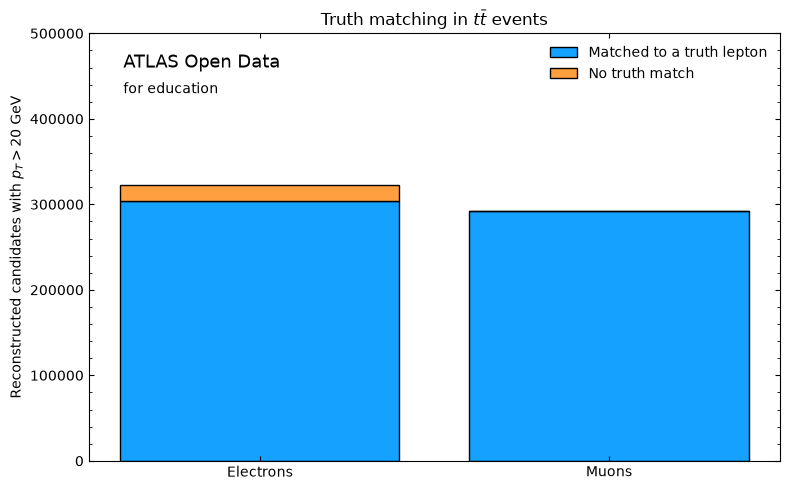

In [19]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

# Each reconstructed candidate will belong to either the matched or unmatched category, so we define them here.
ax.bar(
    particle_names,
    matched_counts,
    color="#15A1FF",
    edgecolor="black",
    label="Matched to a truth lepton",
)

ax.bar(
    particle_names,
    unmatched_counts,
    bottom=matched_counts,
    color="#FF9F40",
    edgecolor="black",
    label="No truth match",
)

# Build general plot structure
ax.set_ylabel(r"Reconstructed candidates with $p_T>20$ GeV")
ax.set_title(r"Truth matching in $t\bar{t}$ events")
ax.tick_params(which="both",direction="in",top=True,right=True,)
ax.set_ylim(0, 500000)
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.legend(frameon=False,loc="upper right",)

# Add Atlas Open Data text
ax.text(
    0.05,
    0.92,
    "ATLAS Open Data",
    transform=ax.transAxes,
    fontsize=13,
)

ax.text(
    0.05,
    0.86,
    "for education",
    transform=ax.transAxes,
    fontsize=10,
)

plt.tight_layout()
plt.show()

### Findings

Here we see that while greatly outnumbered by matched candidates, unmatched leptons are still a significant factor in our data, even including our cuts and matching criteria. This also shows us that although some leptons may be considered non-prompt, they are still accounted for in the truth record, as the amount of likely non-prompt leptons we viewed prior is far more than what appears to be unmatched. 

While these numbers do indicate the presence of fake leptons via misidentification, we cannot assume these numbers are completely synonymous. As mentioned before, a significant amount of these unmatched candidates may also have arisen from other factors, like the resolution of the detector for this run, or the strictness of our matching requirements. 

## Summary

By now, we've looked at:

- What fake leptons are, the differences between misidentification and non-prompts, and different ways they can arise.
- A case study on ttbar events, where we graphed the amount of leptons produced by each hard scatter, paying attention to how many prompt leptons can arise from a ttbar event.
- A case study on Photon Conversion, where we plotted amounts for mass in diphoton and electron-photon events, indicating electron production as a result of higgs decay.
- One example of misidentified objects and a sample truth matching exercise, looking at how many leptons don't match our simulated signal record.

If you would like to delve deeper into fake leptons and their role in analysis, here are a few suggestions to continue your learning!

- Run similar protocols on other samples and see how non-prompts and fakes vary between different sample types.
- Check leptons for their isolation from other physics objects to suppress jet or hadron-related leptonic decays.
- Check the dependence on momentum or detector position while trutch matching to identify possible sources of misidentification.
- For deeper explanations, you may read ATLAS publications pertaining to fake leptons, like [this one!](https://cds.cern.ch/record/2842463/files/2211.16178.pdf)